### **01_Limpieza_de_datos**

Desarrollado por: Ing. M. Wara López L.

### Importación de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Carga del dataset

In [2]:
df = pd.read_csv('dataset_batteries_to_use.csv')

In [3]:
df.head()

,Edad_Bateria,Horas_Uso_Diario,Usuario_Gamer,Capacidad_Diseño,Ciclos_Carga,Uso_CPU,Uso_GPU,Consumo_Energia,Temperatura_Promedio,Capacidad_Carga_Completa,Salud_Bateria
0,5,9.797617,0,57884,1267,64.587764,43.887115,84.366245,35.645636,44961.935220,76.923383
1,9,7.101557,0,63824,13986,45.542182,36.534144,80.629042,31.782432,46619.665590,73.496153
2,9,10.085255,0,79414,1500,64.640516,52.238349,87.853504,32.122879,63343.419989,-10.000000
3,5,7.946047,0,61142,1153,55.095724,30.535647,69.686012,30.371133,50407.438833,79.742100
4,-3,9.628460,0,50956,6886,60.145756,36.749489,64.734123,27.536232,34757.377982,67.882552


### Exploración inicial del dataset

In [4]:
df.shape

(1220, 11)

In [5]:
df.dtypes

Edad_Bateria                  int64
Horas_Uso_Diario            float64
Usuario_Gamer                 int64
Capacidad_Diseño              int64
Ciclos_Carga                  int64
Uso_CPU                     float64
Uso_GPU                     float64
Consumo_Energia             float64
Temperatura_Promedio        float64
Capacidad_Carga_Completa    float64
Salud_Bateria               float64
dtype: object

In [6]:
df["Usuario_Gamer"] = df["Usuario_Gamer"].astype("object")

In [7]:
df.dtypes

Edad_Bateria                  int64
Horas_Uso_Diario            float64
Usuario_Gamer                object
Capacidad_Diseño              int64
Ciclos_Carga                  int64
Uso_CPU                     float64
Uso_GPU                     float64
Consumo_Energia             float64
Temperatura_Promedio        float64
Capacidad_Carga_Completa    float64
Salud_Bateria               float64
dtype: object

In [8]:
df.describe()

,Edad_Bateria,Horas_Uso_Diario,Capacidad_Diseño,Ciclos_Carga,Uso_CPU,Uso_GPU,Consumo_Energia,Temperatura_Promedio,Capacidad_Carga_Completa,Salud_Bateria
count,1220.000000,1220.000000,1220.000000,1220.000000,1142.000000,1164.000000,1166.000000,1170.000000,1220.000000,1164.000000
mean,6.765574,6.455593,61965.800820,1939.936066,61.227280,49.097107,120.143132,33.106340,41312.040844,81.651037
std,11.120230,3.149675,10130.455446,2978.978406,38.614224,38.893030,156.276314,25.673989,33236.472100,25.435351
min,-3.000000,1.002497,45002.000000,0.000000,9.151884,5.000000,20.133013,-20.000000,-79263.000000,-10.000000
25%,2.000000,3.734475,53208.000000,596.750000,35.525100,25.387978,54.774767,28.389994,39838.626893,74.668093
50%,5.000000,6.336366,61723.000000,1265.000000,53.248439,37.675857,71.131985,30.383585,49416.351879,81.771071
75%,7.000000,9.206696,70693.000000,1500.000000,69.617865,52.243811,90.197064,32.466739,59262.045880,92.868974
max,60.000000,11.986722,79959.000000,14978.000000,199.960415,178.901070,789.000000,150.000000,78634.214027,150.000000


### Detección de errores

In [9]:
# Conteo de valores nulos por variable
num_datos_nulos = df.isnull().sum()

print("📊 CONTEO DE DATOS NULOS:")
print("-" * 50)
print(num_datos_nulos)
print("-" * 50)
total_nulos = num_datos_nulos.sum()
print(f"TOTAL de valores nulos en todas las variables: {total_nulos}")

📊 CONTEO DE DATOS NULOS:
--------------------------------------------------
Edad_Bateria                 0
Horas_Uso_Diario             0
Usuario_Gamer                0
Capacidad_Diseño             0
Ciclos_Carga                 0
Uso_CPU                     78
Uso_GPU                     56
Consumo_Energia             54
Temperatura_Promedio        50
Capacidad_Carga_Completa     0
Salud_Bateria               56
dtype: int64
--------------------------------------------------
TOTAL de valores nulos en todas las variables: 294


In [10]:
# Definir la función para contar valores atípicos
def contar_valores_atipicos(columna):
    Q1 = columna.quantile(0.25)
    Q3 = columna.quantile(0.75)
    IQR = Q3 - Q1
    umbral_inferior = Q1 - 1.5 * IQR
    umbral_superior = Q3 + 1.5 * IQR
    valores_atipicos = ((columna < umbral_inferior) | (columna > umbral_superior)).sum()
    return valores_atipicos
# Lista de variables cuantitativas de tu dataset
variables_cuantitativas = df.select_dtypes(include=["int64","float64"]).columns
# Aplicar la función a cada variable
print("📊 CONTEO DE VALORES ATÍPICOS (OUTLIERS):")
print("-" * 50)
for variable in variables_cuantitativas:
    num_valores_atipicos = contar_valores_atipicos(df[variable])
    print(f"{variable:25} → {num_valores_atipicos:5} valores atípicos")

print("-" * 50)
total_atipicos = sum([contar_valores_atipicos(df[var]) for var in variables_cuantitativas])
print(f"TOTAL de valores atípicos en todas las variables: {total_atipicos}")

📊 CONTEO DE VALORES ATÍPICOS (OUTLIERS):
--------------------------------------------------
Edad_Bateria              →    67 valores atípicos
Horas_Uso_Diario          →     0 valores atípicos
Capacidad_Diseño          →     0 valores atípicos
Ciclos_Carga              →   124 valores atípicos
Uso_CPU                   →   118 valores atípicos
Uso_GPU                   →   127 valores atípicos
Consumo_Energia           →   125 valores atípicos
Temperatura_Promedio      →   126 valores atípicos
Capacidad_Carga_Completa  →   122 valores atípicos
Salud_Bateria             →    93 valores atípicos
--------------------------------------------------
TOTAL de valores atípicos en todas las variables: 902


In [11]:
duplicados = df.duplicated().sum()
print("📊 CONTEO DE DATOS DUPLICADOS:")
print("-" * 50)
print(f"TOTAL de valores duplicados: {duplicados}")

📊 CONTEO DE DATOS DUPLICADOS:
--------------------------------------------------
TOTAL de valores duplicados: 20


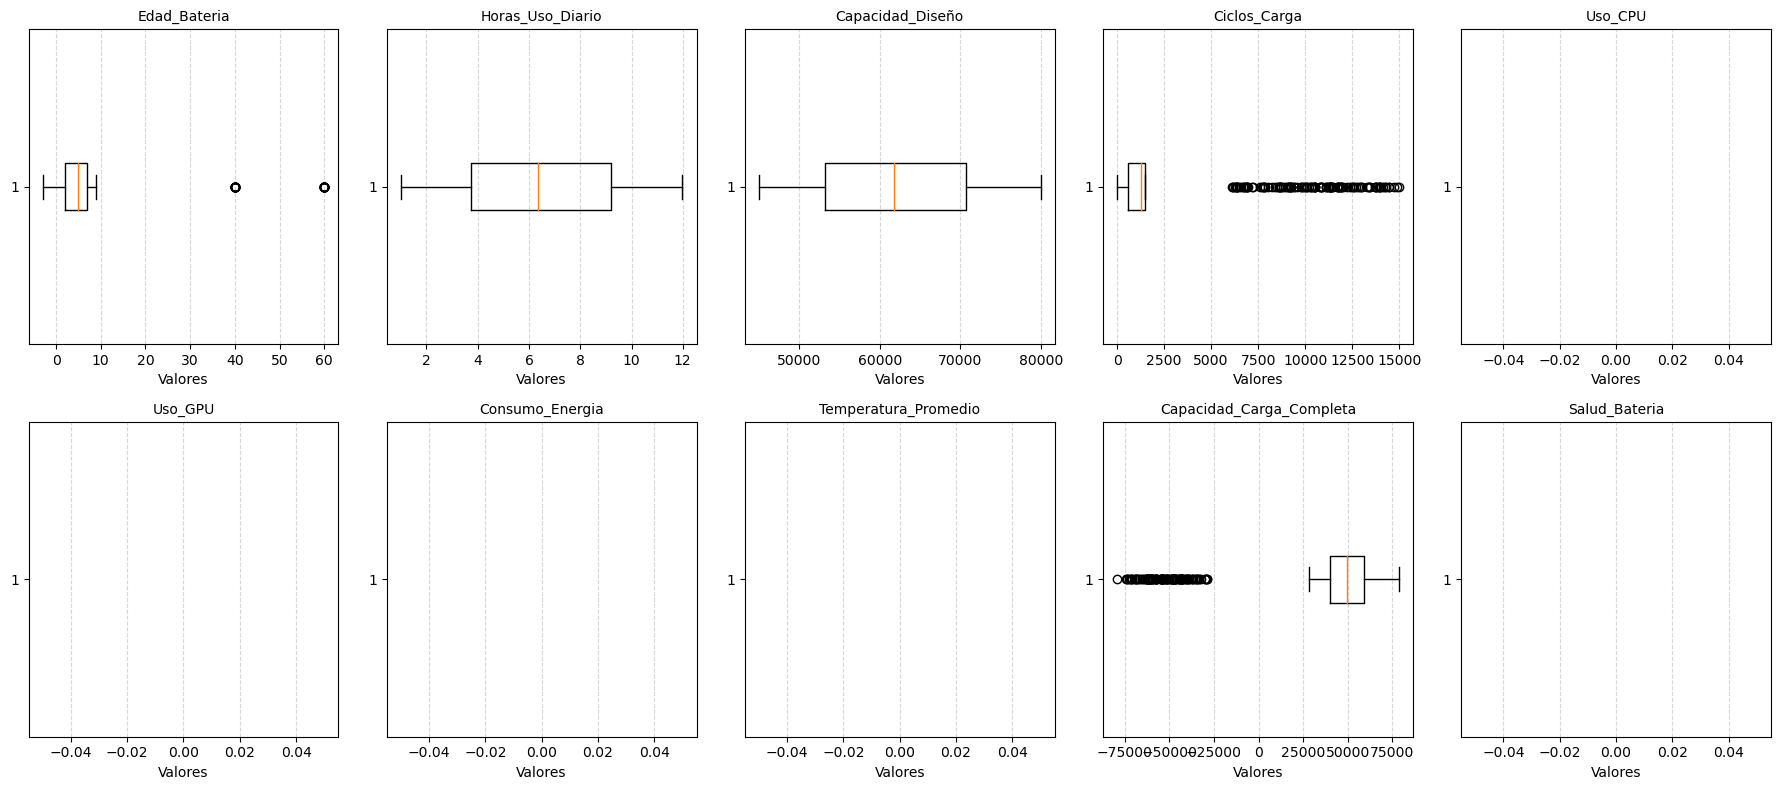

In [12]:
variables = [
    "Edad_Bateria",
    "Horas_Uso_Diario",
    "Capacidad_Diseño",
    "Ciclos_Carga",
    "Uso_CPU",
    "Uso_GPU",
    "Consumo_Energia",
    "Temperatura_Promedio",
    "Capacidad_Carga_Completa",
    "Salud_Bateria"
]

# Crear matriz de gráficos
fig, axes = plt.subplots( nrows=2,ncols=5,figsize=(18, 8))
axes = axes.flatten()
for i, variable in enumerate(variables):
    axes[i].boxplot(df[variable], vert=False)
    axes[i].set_title(variable, fontsize=10)
    axes[i].set_xlabel("Valores")
    axes[i].grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
df.groupby("Usuario_Gamer")[ ["Uso_CPU", "Uso_GPU", "Consumo_Energia", "Temperatura_Promedio"]].mean()

,Uso_CPU,Uso_GPU,Consumo_Energia,Temperatura_Promedio
Usuario_Gamer,,,,
0,58.579273,45.314746,119.174834,32.706910
1,83.571207,81.700429,128.662523,36.601352


In [14]:
df[df["Ciclos_Carga"] > 1500]["Ciclos_Carga"].sort_values()

459      6117
359      6148
382      6179
908      6243
1149     6295
        ...  
354     14462
364     14469
752     14741
295     14903
16      14978
Name: Ciclos_Carga, Length: 124, dtype: int64

In [15]:
df[df["Consumo_Energia"] > 150]["Consumo_Energia"].sort_values()

794     304.0
970     313.0
853     315.0
589     318.0
151     318.0
        ...  
44      764.0
573     772.0
282     779.0
548     785.0
1031    789.0
Name: Consumo_Energia, Length: 125, dtype: float64

In [16]:
df[df["Salud_Bateria"] < 50]["Salud_Bateria"]

2      -10.0
27     -10.0
75     -10.0
87       0.0
118    -10.0
122    -10.0
123    -10.0
129    -10.0
164      0.0
169      0.0
181      0.0
187      0.0
205    -10.0
226    -10.0
248    -10.0
267    -10.0
312    -10.0
346    -10.0
352    -10.0
353      0.0
375      0.0
378    -10.0
387    -10.0
407      0.0
421      0.0
442    -10.0
458      0.0
471      0.0
475    -10.0
495    -10.0
520      0.0
568      0.0
607    -10.0
608    -10.0
634    -10.0
637    -10.0
679      0.0
695      0.0
699    -10.0
727    -10.0
732      0.0
749      0.0
761      0.0
767      0.0
788      0.0
803    -10.0
812      0.0
822    -10.0
830      0.0
852      0.0
897    -10.0
935    -10.0
1007   -10.0
1063     0.0
1079   -10.0
1109     0.0
1196   -10.0
Name: Salud_Bateria, dtype: float64

### Corrección de datos

In [17]:
# 1. Edad de batería
df.loc[(df["Edad_Bateria"] < 0) | (df["Edad_Bateria"] > 20),"Edad_Bateria"] = np.nan

# 2. Temperatura promedio
# Rango razonable para una batería/equipo
df.loc[(df["Temperatura_Promedio"] < 0) |  (df["Temperatura_Promedio"] > 80), "Temperatura_Promedio"] = np.nan

# 3. Capacidad de carga completa negativa
df.loc[df["Capacidad_Carga_Completa"] < 0,  "Capacidad_Carga_Completa"] = np.nan

# 4. Salud de batería fuera de rango
df.loc[ (df["Salud_Bateria"] < 0) |  (df["Salud_Bateria"] > 100), "Salud_Bateria"] = np.nan

# 5. Uso CPU fuera de porcentaje válido
df.loc[ (df["Uso_CPU"] < 0) | (df["Uso_CPU"] > 100), "Uso_CPU"] = np.nan

# 6. Uso GPU fuera de porcentaje válido
df.loc[ (df["Uso_GPU"] < 0) |  (df["Uso_GPU"] > 100), "Uso_GPU"] = np.nan

# 7. Ciclos de carga
mediana_ciclos = df.loc[df["Ciclos_Carga"] <= 1500, "Ciclos_Carga"].median()
df.loc[df["Ciclos_Carga"] > 1500,"Ciclos_Carga"] = mediana_ciclos

# 8. Consumo energético
# El dataset original tiene valores hasta aproximadamente 150
mediana_consumo = df.loc[ df["Consumo_Energia"] <= 150, "Consumo_Energia"].median()
df.loc[ df["Consumo_Energia"] > 150, "Consumo_Energia"] = mediana_consumo

# 9. Salud de batería igual a cero
# Casos generados artificialmente
mediana_salud = df.loc[df["Salud_Bateria"] > 50,"Salud_Bateria"].median()
df.loc[ df["Salud_Bateria"] == 0, "Salud_Bateria"] = mediana_salud

### Imputación de valores faltantes

In [18]:
variables_numericas = [
    'Edad_Bateria',
    'Horas_Uso_Diario',
    'Capacidad_Diseño',
    'Ciclos_Carga',
    'Uso_CPU',
    'Uso_GPU',
    'Consumo_Energia',
    'Temperatura_Promedio',
    'Capacidad_Carga_Completa',
    'Salud_Bateria'
]

for variable in variables_numericas:
    df[variable].fillna(df[variable].median(), inplace=True)

In [19]:
# Eliminar registros duplicados
df = df.drop_duplicates().reset_index(drop=True)

### Validación final

In [20]:
# Conteo de valores nulos por variable
num_datos_nulos = df.isnull().sum()

print("📊 CONTEO DE DATOS NULOS:")
print("-" * 50)
print(num_datos_nulos)
print("-" * 50)
total_nulos = num_datos_nulos.sum()
print(f"TOTAL de valores nulos en todas las variables: {total_nulos}")

📊 CONTEO DE DATOS NULOS:
--------------------------------------------------
Edad_Bateria                0
Horas_Uso_Diario            0
Usuario_Gamer               0
Capacidad_Diseño            0
Ciclos_Carga                0
Uso_CPU                     0
Uso_GPU                     0
Consumo_Energia             0
Temperatura_Promedio        0
Capacidad_Carga_Completa    0
Salud_Bateria               0
dtype: int64
--------------------------------------------------
TOTAL de valores nulos en todas las variables: 0


In [21]:
# Definir la función para contar valores atípicos
def contar_valores_atipicos(columna):
    Q1 = columna.quantile(0.25)
    Q3 = columna.quantile(0.75)
    IQR = Q3 - Q1
    umbral_inferior = Q1 - 1.5 * IQR
    umbral_superior = Q3 + 1.5 * IQR
    valores_atipicos = ((columna < umbral_inferior) | (columna > umbral_superior)).sum()
    return valores_atipicos
# Lista de variables cuantitativas de tu dataset
variables_cuantitativas = df.select_dtypes(include=["int64","float64"]).columns
# Aplicar la función a cada variable
print("📊 CONTEO DE VALORES ATÍPICOS (OUTLIERS):")
print("-" * 50)
for variable in variables_cuantitativas:
    num_valores_atipicos = contar_valores_atipicos(df[variable])
    print(f"{variable:25} → {num_valores_atipicos:5} valores atípicos")

print("-" * 50)
total_atipicos = sum([contar_valores_atipicos(df[var]) for var in variables_cuantitativas])
print(f"TOTAL de valores atípicos en todas las variables: {total_atipicos}")

📊 CONTEO DE VALORES ATÍPICOS (OUTLIERS):
--------------------------------------------------
Edad_Bateria              →     0 valores atípicos
Horas_Uso_Diario          →     0 valores atípicos
Capacidad_Diseño          →     0 valores atípicos
Ciclos_Carga              →     0 valores atípicos
Uso_CPU                   →     9 valores atípicos
Uso_GPU                   →    64 valores atípicos
Consumo_Energia           →    22 valores atípicos
Temperatura_Promedio      →    28 valores atípicos
Capacidad_Carga_Completa  →     0 valores atípicos
Salud_Bateria             →     0 valores atípicos
--------------------------------------------------
TOTAL de valores atípicos en todas las variables: 123


In [22]:
duplicados = df.duplicated().sum()
print("📊 CONTEO DE DATOS DUPLICADOS:")
print("-" * 50)
print(f"TOTAL de valores duplicados: {duplicados}")

📊 CONTEO DE DATOS DUPLICADOS:
--------------------------------------------------
TOTAL de valores duplicados: 0


In [23]:
df.describe()

,Edad_Bateria,Horas_Uso_Diario,Capacidad_Diseño,Ciclos_Carga,Uso_CPU,Uso_GPU,Consumo_Energia,Temperatura_Promedio,Capacidad_Carga_Completa,Salud_Bateria
count,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,4.35250,6.435078,62049.919167,1010.306667,49.824466,36.999428,68.704792,30.475796,51730.363459,82.712841
std,2.79847,3.149664,10096.807179,504.638314,17.491123,16.316395,19.674907,2.436122,10995.177801,9.202459
min,0.00000,1.002497,45002.000000,0.000000,9.151884,5.000000,20.133013,23.105802,28181.020459,59.840266
25%,2.00000,3.722104,53583.250000,624.750000,36.242987,25.859674,55.517711,29.053393,43610.944638,76.497282
50%,4.00000,6.322145,61888.000000,1185.500000,49.918823,35.230937,67.811399,30.420018,51569.088876,81.445330
75%,7.00000,9.162563,70734.750000,1500.000000,61.292733,43.932050,79.876808,31.925221,59312.703867,89.139232
max,9.00000,11.986722,79959.000000,1500.000000,100.000000,98.339932,137.154936,39.934239,78634.214027,100.000000


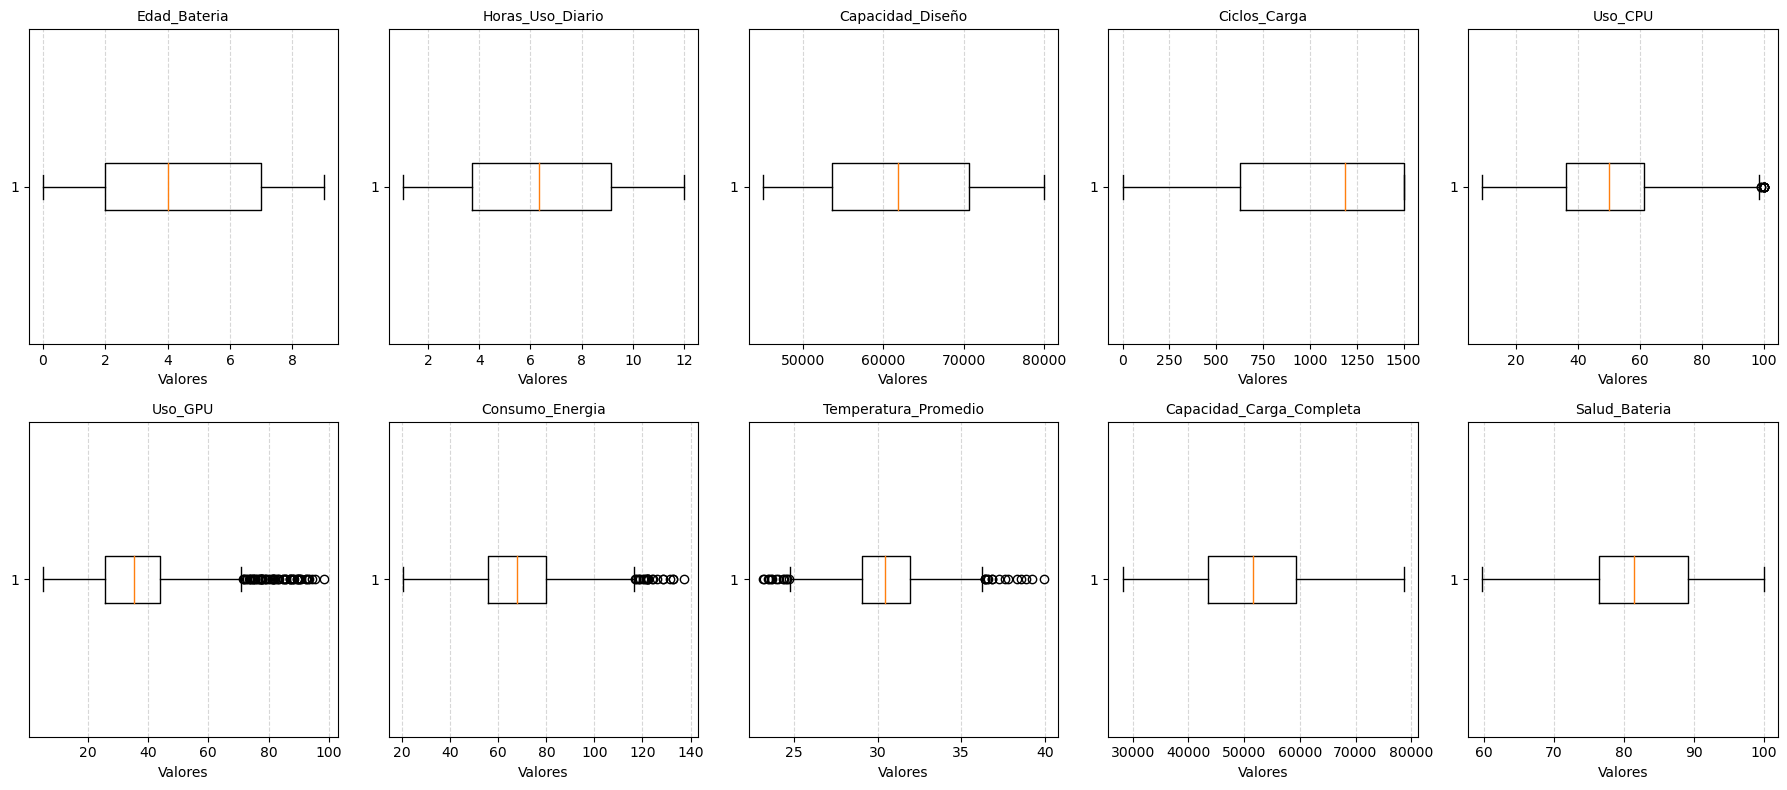

In [24]:
variables = [
    "Edad_Bateria",
    "Horas_Uso_Diario",
    "Capacidad_Diseño",
    "Ciclos_Carga",
    "Uso_CPU",
    "Uso_GPU",
    "Consumo_Energia",
    "Temperatura_Promedio",
    "Capacidad_Carga_Completa",
    "Salud_Bateria"
]

# Crear matriz de gráficos
fig, axes = plt.subplots( nrows=2,ncols=5,figsize=(18, 8))
axes = axes.flatten()
for i, variable in enumerate(variables):
    axes[i].boxplot(df[variable], vert=False)
    axes[i].set_title(variable, fontsize=10)
    axes[i].set_xlabel("Valores")
    axes[i].grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Conclusiones del proceso de limpieza de datos

Después del proceso de limpieza, el conjunto de datos presenta una estructura consistente y adecuada para continuar con las siguientes etapas de análisis. Se trataron los valores: faltantes, inconsistencias y registros duplicados identificados durante la revisión inicial.

En el análisis de valores atípicos se aplicó un criterio basado en el comportamiento esperado de cada variable. Algunos valores extremos fueron corregidos debido a que no representaban condiciones coherentes del sistema; sin embargo, se conservaron observaciones elevadas en variables como: Uso_CPU, Uso_GPU y Temperatura_Promedio, debido a que corresponden a escenarios posibles de alta demanda computacional y no representan errores de medición.

Esta evaluación permitió mantener información relevante del comportamiento del sistema, evitando eliminar datos válidos únicamente por encontrarse fuera del rango habitual. Finalmente, la validación mediante estadísticas descriptivas y visualizaciones confirmó que las variables presentan distribuciones coherentes y que el dataset se encuentra preparado para realizar el análisis exploratorio.

#### Resumen del proceso de limpieza

| Problema detectado     | Tratamiento aplicado                                                        | Resultado                                                        |
| ---------------------- | --------------------------------------------------------------------------- | ---------------------------------------------------------------- |
| Valores faltantes      | Imputación según el comportamiento de cada variable                         | Dataset completo                                                 |
| Valores inconsistentes | Corrección mediante rangos esperados y reglas del dominio                   | Variables validadas                                              |
| Valores atípicos       | Evaluación mediante boxplots y análisis del comportamiento de las variables | Se corrigieron errores y se conservaron valores extremos válidos |
| Registros duplicados   | Identificación y eliminación de registros repetidos                         | Dataset sin duplicados                                           |
| Validación final       | Revisión estadística y visual                                               | Dataset preparado para análisis                                  |


In [25]:
print("Dimensiones finales:", df.shape)
print("Valores nulos:", df.isnull().sum().sum())
print("Duplicados:", df.duplicated().sum())

Dimensiones finales: (1200, 11)
Valores nulos: 0
Duplicados: 0
